In [102]:

from stimbposd import BPOSD
import matplotlib.pyplot as plt
from sympy.abc import x, y
from qldpc import codes
from qldpc.objects import Pauli
from graph_helper_functions import deform_code_for_logical
import numpy as np
import stim
import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)
from deform_triangular_lattice import deform_logical_to_tri_lattice

import importlib
import deform_triangular_lattice
importlib.reload(deform_triangular_lattice)

from deform_triangular_lattice import deform_logical_to_tri_lattice

In [103]:
a = x**3+y+y**2
b = y**3+x+x**2
orders = {x: 12, y: 6}


def BB144Code():
    return codes.BBCode(orders=orders, poly_a=a, poly_b=b)



Logical 0 weight 26
Logical 1 weight 38
Logical 2 weight 24
Logical 3 weight 36
Logical 4 weight 16
Logical 5 weight 34
Logical 6 weight 34
Logical 7 weight 36
Logical 8 weight 24
Logical 9 weight 22
Logical 10 weight 26
Logical 11 weight 26


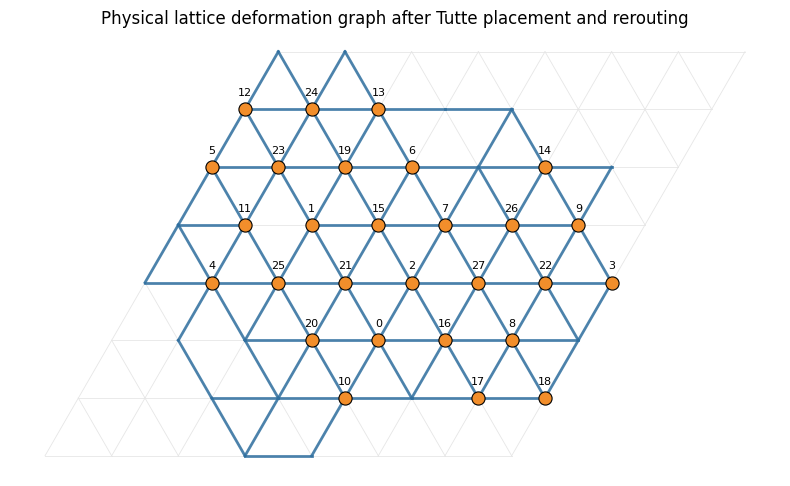

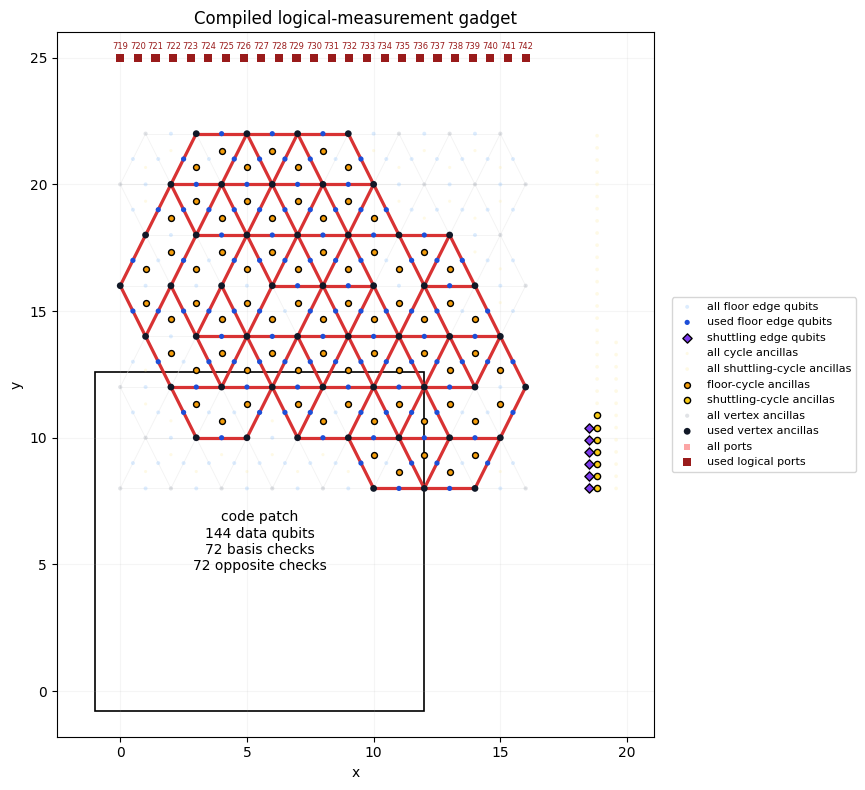

In [ ]:
BB_code = BB144Code()
for i, logical in enumerate(BB_code.get_logical_ops(Pauli.Z)):
    print("Logical", i, "weight", np.sum(np.array(logical)))
def_res = deform_code_for_logical(BB_code.matrix, Pauli.Z, BB_code.get_logical_ops(Pauli.Z)[8])
def_res = deform_logical_to_tri_lattice(def_res, plot=True, shuttling_threshold=)

stabilizer weight summary
BB basis        : rows= 72, min= 6, mean= 6.00, max= 6, distribution={6: 72}
BB opposite     : rows= 72, min= 6, mean= 7.07, max=14, distribution={6: 36, 7: 18, 8: 6, 9: 7, 10: 2, 11: 2, 14: 1}
gadget basis    : rows= 55, min= 2, mean= 4.76, max= 8, distribution={2: 11, 3: 5, 4: 11, 5: 4, 6: 11, 7: 9, 8: 4}
gadget opposite : rows= 65, min= 3, mean= 3.40, max= 6, distribution={3: 49, 4: 9, 5: 4, 6: 3}
all basis       : rows=127, min= 2, mean= 5.46, max= 8, distribution={2: 11, 3: 5, 4: 11, 5: 4, 6: 83, 7: 9, 8: 4}
all opposite    : rows=137, min= 3, mean= 5.33, max=14, distribution={3: 49, 4: 9, 5: 4, 6: 39, 7: 18, 8: 6, 9: 7, 10: 2, 11: 2, 14: 1}

printed stabilizer weight histograms

BB basis
  weight  6 | ############################################ 72

BB opposite
  weight  6 | ############################################ 36
  weight  7 | ######################                       18
  weight  8 | #######                                      6
  weight  9

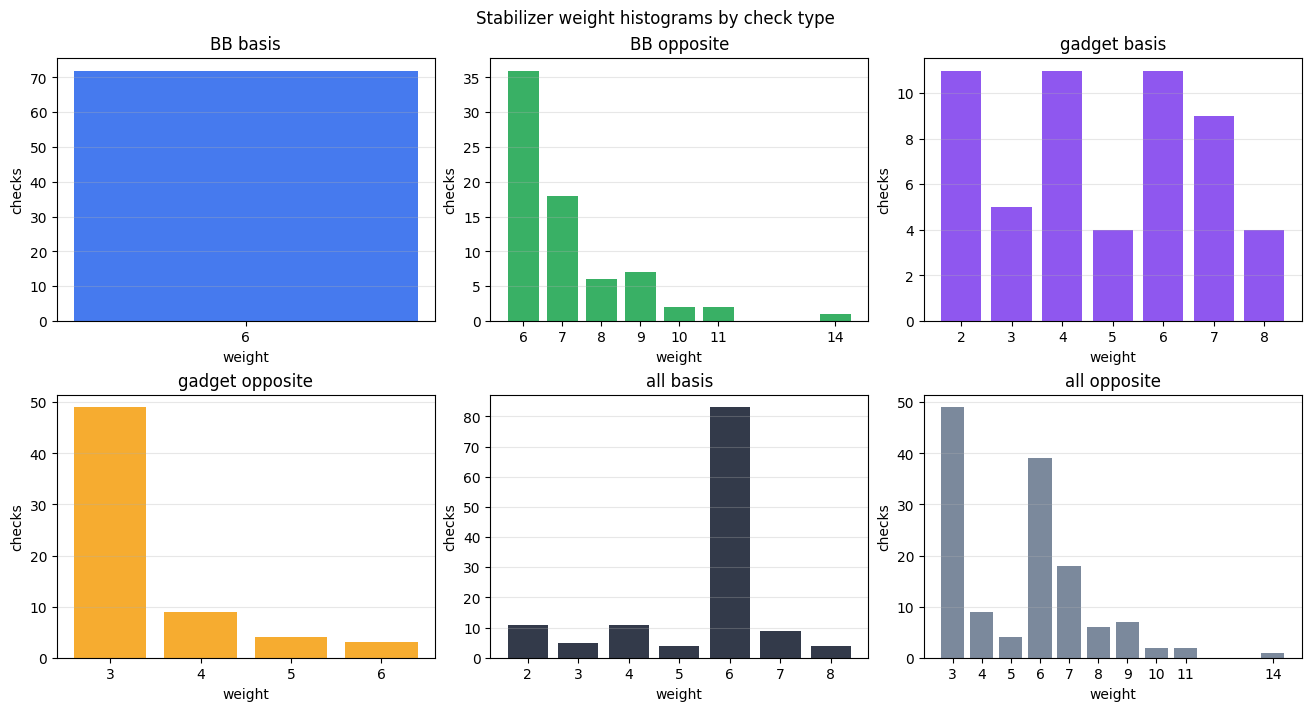

In [105]:
# Stabilizer weight statistics for the current deformation result.
def _row_weights(matrix):
    M = np.asarray(matrix, dtype=np.uint8)
    if M.size == 0:
        return np.array([], dtype=int)
    return np.sum(M, axis=1).astype(int)


def _weight_distribution(weights):
    values, counts = np.unique(weights, return_counts=True)
    return {int(v): int(c) for v, c in zip(values, counts)}


def _print_weight_histogram(name, weights, width=44):
    print(f"\n{name}")
    if len(weights) == 0:
        print("  no rows")
        return
    dist = _weight_distribution(weights)
    max_count = max(dist.values())
    for weight, count in dist.items():
        bar = "#" * max(1, int(round(width * count / max_count)))
        print(f"  weight {weight:2d} | {bar:<{width}} {count}")


weight_sets = {
    "BB basis": _row_weights(def_res["BB_H_basis"]),
    "BB opposite": _row_weights(def_res["BB_H_opposite"]),
    "gadget basis": _row_weights(def_res["gadget_H_basis"]),
    "gadget opposite": _row_weights(def_res["gadget_H_opposite"]),
    "all basis": _row_weights(def_res["H_basis_def"]),
    "all opposite": _row_weights(def_res["H_opposite_basis_def"]),
}

print("stabilizer weight summary")
for name, weights in weight_sets.items():
    if len(weights) == 0:
        print(f"{name:16s}: no rows")
        continue
    print(
        f"{name:16s}: rows={len(weights):3d}, "
        f"min={weights.min():2d}, mean={weights.mean():5.2f}, "
        f"max={weights.max():2d}, distribution={_weight_distribution(weights)}"
    )

print("\nprinted stabilizer weight histograms")
for name, weights in weight_sets.items():
    _print_weight_histogram(name, weights)

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
colors = ["#2563eb", "#16a34a", "#7c3aed", "#f59e0b", "#0f172a", "#64748b"]

for ax, (name, weights), color in zip(axes.flat, weight_sets.items(), colors):
    if len(weights) == 0:
        ax.set_title(name)
        ax.axis("off")
        continue
    dist = _weight_distribution(weights)
    xs = list(dist.keys())
    ys = list(dist.values())
    ax.bar(xs, ys, color=color, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel("weight")
    ax.set_ylabel("checks")
    ax.set_xticks(xs)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Stabilizer weight histograms by check type")
plt.show()


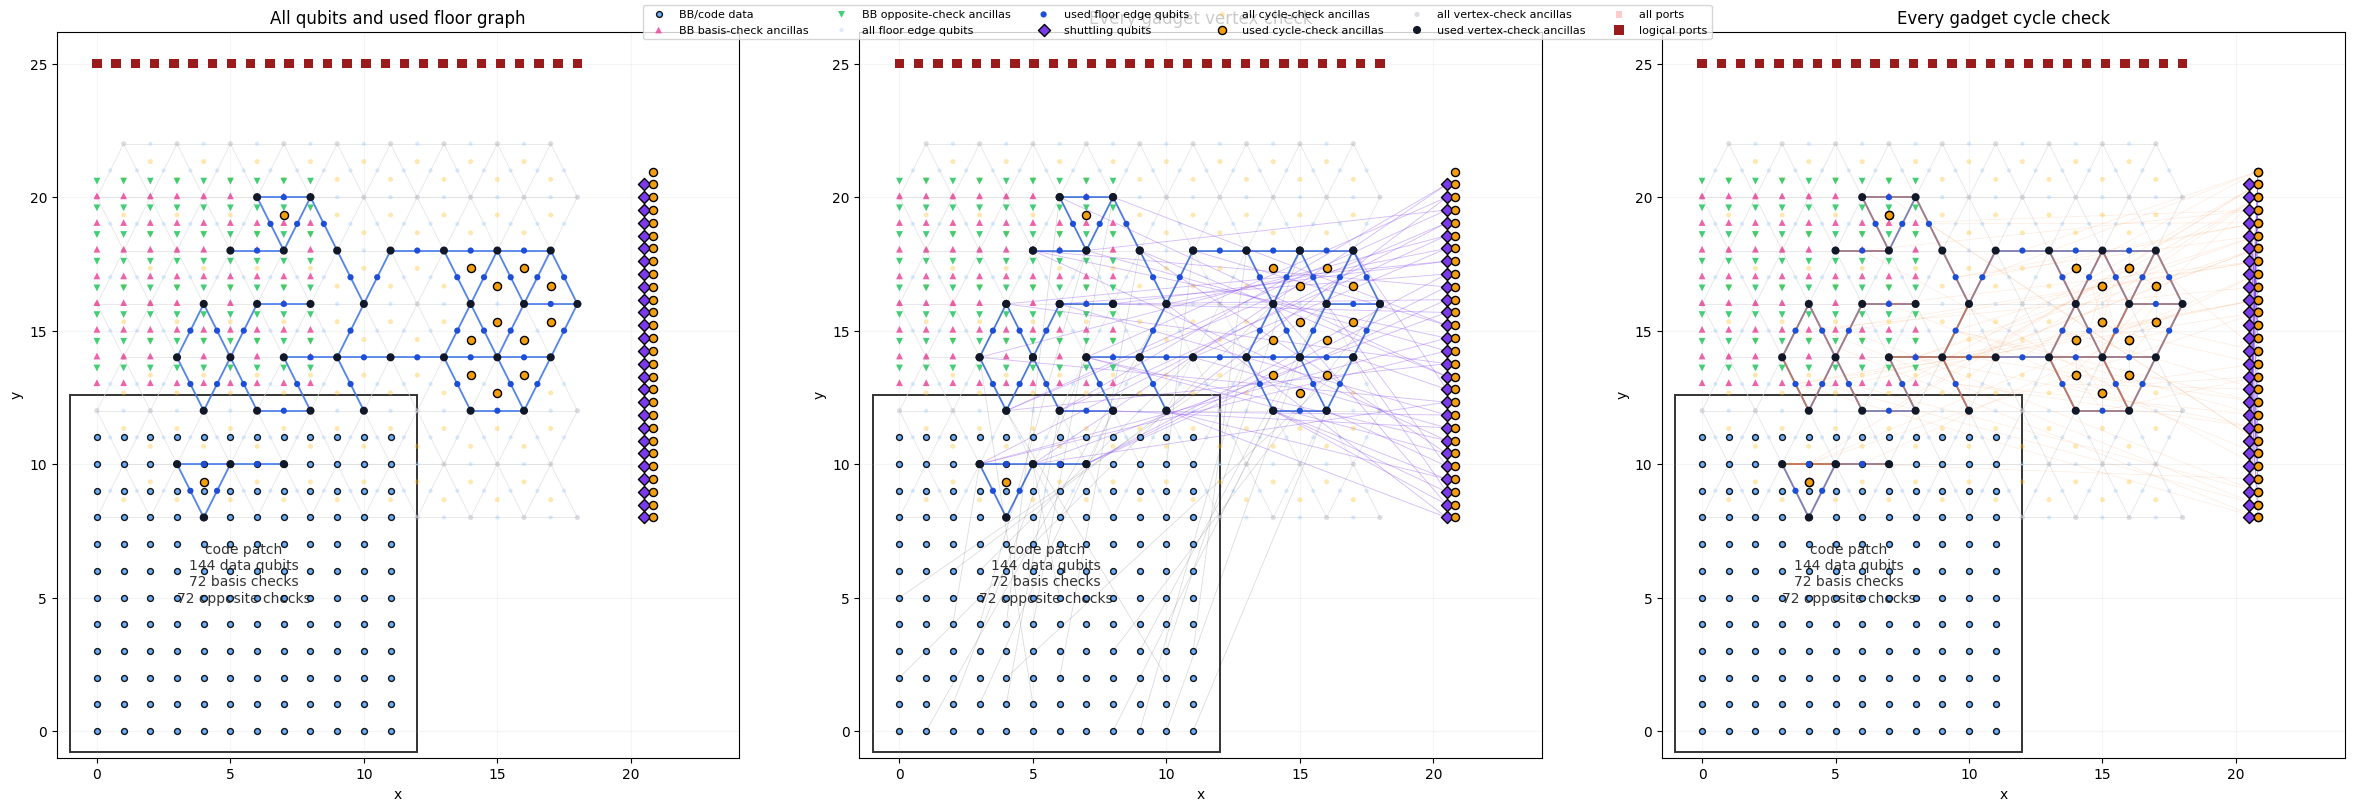

In [86]:
# Debug visualization: all qubits, all gadget vertex checks, and all gadget cycle checks.
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle


def plot_gadget_qubits_and_all_checks(tri_def, *, show_labels=False):
    coords = {int(q): tuple(xy) for q, xy in tri_def["coords"].items()}
    template = tri_def["fixed_template"]
    n_data = int(tri_def["n_data"])

    floor_used = set(map(int, tri_def.get("floor_edge_qubits_used", [])))
    shuttles = set(map(int, tri_def.get("shuttling_edge_qubits", [])))
    used_cycles = sorted({
        int(q)
        for qs in tri_def.get("gadget_opposite_to_ancillas", {}).values()
        for q in qs
        if q is not None
    })
    used_vertices = sorted(map(int, tri_def.get("gadget_basis_to_ancilla", {}).values()))
    logical_ports = sorted(map(int, tri_def.get("logical_support_to_port_qubit", {}).values()))

    fig, axes = plt.subplots(1, 3, figsize=(24, 8), constrained_layout=True)

    def xy(q):
        return coords[int(q)]

    def add_segments(ax, segments, *, color, lw=0.7, alpha=1.0, zorder=1, linestyle="solid"):
        if not segments:
            return
        lc = LineCollection(segments, colors=color, linewidths=lw, alpha=alpha, linestyles=linestyle, zorder=zorder)
        ax.add_collection(lc)

    def draw_code_patch(ax):
        if "code_patch_rect" in tri_def:
            x0, y0, w, h = tri_def["code_patch_rect"]
            ax.add_patch(Rectangle((x0, y0), w, h, facecolor="white", edgecolor="0.2", lw=1.4, zorder=0))
            label = tri_def.get("code_patch_label", "code patch")
            ax.text(x0 + w / 2, y0 + h / 2, label, ha="center", va="center", fontsize=10, color="0.2", zorder=1)

    def floor_edge_segment(q):
        if int(q) not in template.edge_qubit_to_vertices:
            return None
        a, b = template.edge_qubit_to_vertices[int(q)]
        return [xy(a), xy(b)]

    def draw_floor_background(ax):
        all_floor = [floor_edge_segment(q) for q in template.edge_qubits]
        used_floor = [floor_edge_segment(q) for q in floor_used]
        add_segments(ax, [s for s in all_floor if s is not None], color="0.88", lw=0.65, alpha=0.75, zorder=1)
        add_segments(ax, [s for s in used_floor if s is not None], color="#2563eb", lw=1.35, alpha=0.75, zorder=2)

    def scatter(ax, qubits, *, color, marker="o", size=18, label=None, zorder=5, alpha=1.0, edgecolor="none"):
        qubits = [int(q) for q in qubits if int(q) in coords]
        if not qubits:
            return
        ax.scatter(
            [coords[q][0] for q in qubits],
            [coords[q][1] for q in qubits],
            s=size,
            c=color,
            marker=marker,
            label=label,
            zorder=zorder,
            alpha=alpha,
            edgecolors=edgecolor,
        )
        if show_labels:
            for q in qubits:
                x, y = xy(q)
                ax.text(x, y + 0.12, str(q), ha="center", va="bottom", fontsize=5, color=color, zorder=zorder + 1)

    def draw_all_qubits(ax):
        draw_code_patch(ax)
        draw_floor_background(ax)
        scatter(ax, range(n_data), color="#60a5fa", size=18, label="BB/code data", zorder=6, edgecolor="black", alpha=0.9)
        scatter(ax, template.basis_check_qubits, color="#ec4899", marker="^", size=24, label="BB basis-check ancillas", zorder=6, alpha=0.85)
        scatter(ax, template.opposite_check_qubits, color="#22c55e", marker="v", size=24, label="BB opposite-check ancillas", zorder=6, alpha=0.85)
        scatter(ax, template.edge_qubits, color="#93c5fd", size=9, label="all floor edge qubits", zorder=4, alpha=0.35)
        scatter(ax, floor_used, color="#1d4ed8", size=20, label="used floor edge qubits", zorder=7)
        scatter(ax, shuttles, color="#7c3aed", marker="D", size=38, label="shuttling qubits", zorder=8, edgecolor="black")
        if shuttles:
            shuttle_sorted = sorted(shuttles)
            add_segments(ax, [[xy(a), xy(b)] for a, b in zip(shuttle_sorted, shuttle_sorted[1:])], color="#7c3aed", lw=1.0, alpha=0.45, zorder=3)
        scatter(ax, template.cycle_check_qubits, color="#fbbf24", size=13, label="all cycle-check ancillas", zorder=5, alpha=0.35)
        scatter(ax, used_cycles, color="#f59e0b", size=34, label="used cycle-check ancillas", zorder=8, edgecolor="black")
        scatter(ax, template.vertex_check_qubits, color="#9ca3af", size=14, label="all vertex-check ancillas", zorder=5, alpha=0.35)
        scatter(ax, used_vertices, color="#111827", size=34, label="used vertex-check ancillas", zorder=8)
        scatter(ax, template.port_qubits, color="#fca5a5", marker="s", size=22, label="all ports", zorder=5, alpha=0.55)
        scatter(ax, logical_ports, color="#991b1b", marker="s", size=46, label="logical ports", zorder=9)

    def support_qubits(H, row):
        return np.flatnonzero(np.asarray(H, dtype=np.uint8)[int(row)]).astype(int).tolist()

    def draw_vertex_checks(ax):
        H = np.asarray(tri_def["gadget_H_basis"], dtype=np.uint8)
        row_to_ancilla = tri_def["gadget_basis_to_ancilla"]
        normal_segments = []
        shuttle_segments = []
        for row in range(H.shape[0]):
            anc = int(row_to_ancilla[row])
            if anc not in coords:
                continue
            for q in support_qubits(H, row):
                if q not in coords:
                    continue
                (shuttle_segments if q in shuttles else normal_segments).append([xy(anc), xy(q)])
        add_segments(ax, normal_segments, color="#111827", lw=0.55, alpha=0.16, zorder=4)
        add_segments(ax, shuttle_segments, color="#7c3aed", lw=0.65, alpha=0.32, zorder=5)
        scatter(ax, used_vertices, color="#111827", size=34, label=None, zorder=8)

    def draw_cycle_checks(ax):
        H = np.asarray(tri_def["gadget_H_opposite"], dtype=np.uint8)
        row_to_ancillas = tri_def["gadget_opposite_to_ancillas"]
        floor_support_segments = []
        incidence_segments = []
        shuttle_incidence_segments = []
        for row in range(H.shape[0]):
            support = support_qubits(H, row)
            ancillas = [int(q) for q in row_to_ancillas.get(row, []) if q is not None and int(q) in coords]
            for q in support:
                if q not in shuttles:
                    seg = floor_edge_segment(q)
                    if seg is not None:
                        floor_support_segments.append(seg)
            for anc in ancillas:
                for q in support:
                    if q not in coords:
                        continue
                    (shuttle_incidence_segments if q in shuttles else incidence_segments).append([xy(anc), xy(q)])
        add_segments(ax, floor_support_segments, color="#f97316", lw=1.2, alpha=0.30, zorder=5)
        add_segments(ax, incidence_segments, color="#f97316", lw=0.48, alpha=0.14, zorder=4)
        add_segments(ax, shuttle_incidence_segments, color="#7c3aed", lw=0.6, alpha=0.32, zorder=5)
        scatter(ax, used_cycles, color="#f59e0b", size=34, label=None, zorder=8, edgecolor="black")

    def finish(ax, title):
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        xs = [p[0] for p in coords.values()]
        ys = [p[1] for p in coords.values()]
        ax.set_xlim(min(xs) - 1.5, max(xs) + 2.5)
        ax.set_ylim(min(ys) - 1.0, max(ys) + 1.2)
        ax.grid(True, alpha=0.12)

    draw_all_qubits(axes[0])
    finish(axes[0], "All qubits and used floor graph")

    draw_all_qubits(axes[1])
    draw_vertex_checks(axes[1])
    finish(axes[1], "Every gadget vertex check")

    draw_all_qubits(axes[2])
    draw_cycle_checks(axes[2])
    finish(axes[2], "Every gadget cycle check")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=6, fontsize=8, frameon=True)
    return fig, axes


fig_debug_checks, axes_debug_checks = plot_gadget_qubits_and_all_checks(def_res, show_labels=False)
plt.show()
